# Primer ejercicio

Tiempo de ejecución: 32.5678 segundos


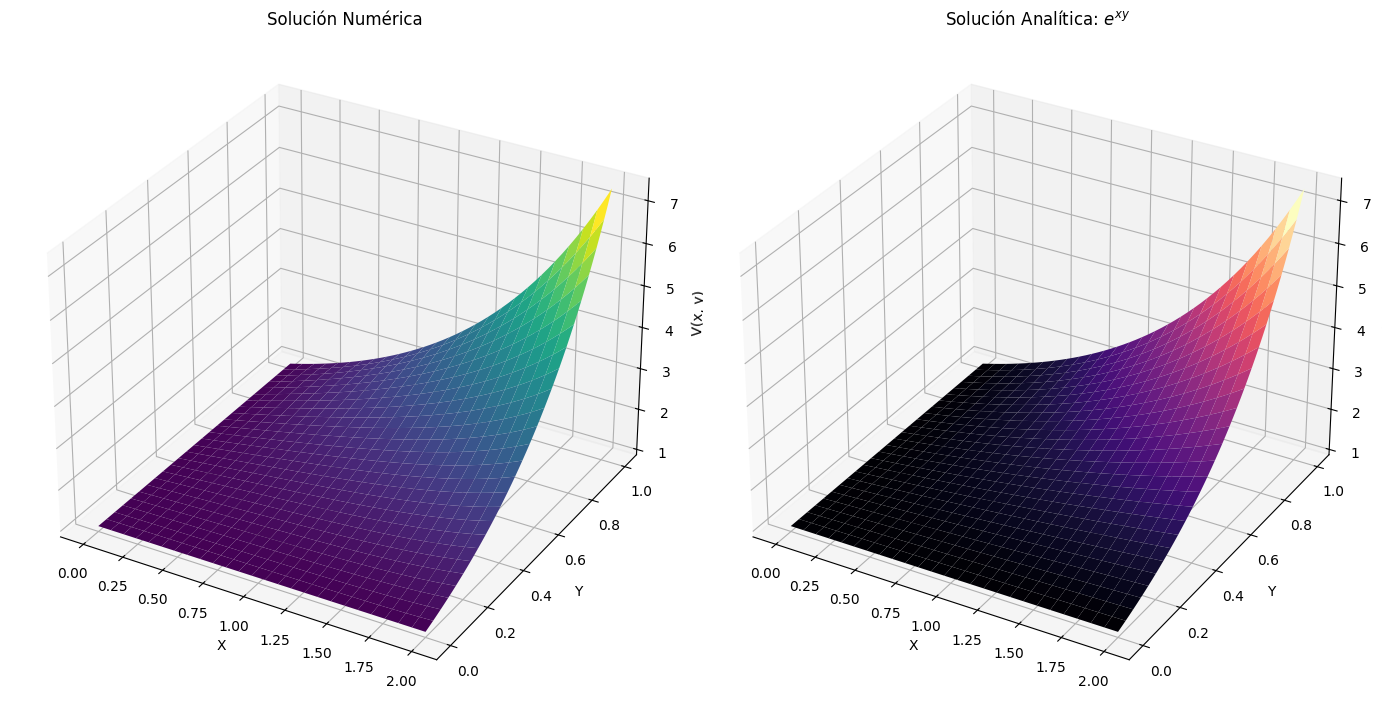

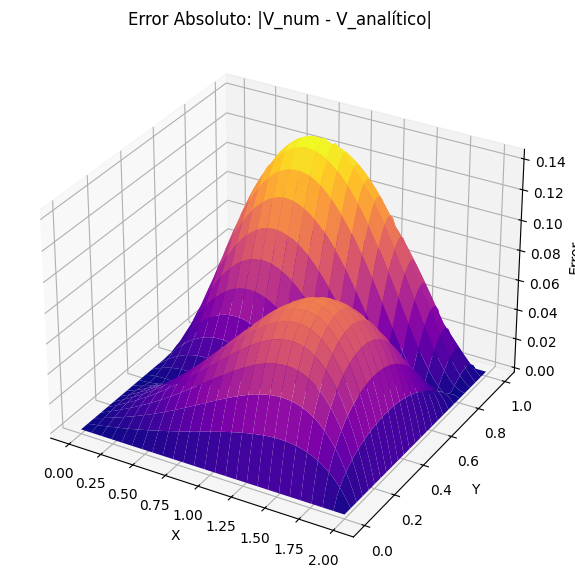

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def initialize_grid(M, N, x_start, x_end, y_start, y_end):
    """
    Inicializa la grilla y la matriz T con las condiciones de contorno dadas.

    Parámetros:
    - M (int): Número de pasos en el eje x.
    - N (int): Número de pasos en el eje y.
    - x_start (float): Valor inicial del rango en x.
    - x_end (float): Valor final del rango en x.
    - y_start (float): Valor inicial del rango en y.
    - y_end (float): Valor final del rango en y.

    Retorna:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.
    - T (ndarray): Matriz inicializada con las condiciones de contorno.
    """
    # Tamaño de la grilla
    h = (x_end - x_start) / M
    k = (y_end - y_start) / N

    # Creación de la grilla
    x = np.linspace(x_start, x_end, M + 1)
    y = np.linspace(y_start, y_end, N + 1)
    X, Y = np.meshgrid(x, y)

    # Inicialización de la matriz T
    T = np.zeros((len(Y), len(X)))

    # Condiciones de contorno
    T[:, 0] = 1.0                     # V(0, y) = 1
    T[:, -1] = np.exp(2 * Y[:, -1])    # V(2, y) = e^(2y)
    T[0, :] = 1.0                     # V(x, 0) = 1
    T[-1, :] = np.exp(X[-1, :])       # V(x, 1) = e^x

    return X, Y, T

def poisson_fuente(X, Y):
    """
    Define el término fuente: (x^2 + y^2) * exp(x*y).

    Parámetros:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.

    Retorna:
    - G (ndarray): Matriz con los valores del término fuente.
    """
    G = (X**2 + Y**2) * np.exp(X * Y)
    return G

def solve_poisson(T, source, M, N, h, k, tol=1e-6):
    """
    Aproximación de la solución de la ecuación de Poisson utilizando el método de diferencias finitas.

    Parámetros:
    - T (ndarray): Matriz inicial con condiciones de contorno.
    - source (ndarray): Término fuente.
    - M (int): Número de pasos en el eje x.
    - N (int): Número de pasos en el eje y.
    - h (float): Tamaño del paso en x.
    - k (float): Tamaño del paso en y.
    - tol (float): Tolerancia para el criterio de convergencia.

    Retorna:
    - T (ndarray): Matriz con la solución aproximada.
    """
    T_new = T.copy()
    delta = 1.0
    while delta > tol:
        delta = 0.0
        # Iteración sobre los puntos internos
        for i in range(1, N):
            for j in range(1, M):
                T_new[i, j] = (
                    ((T[i + 1, j] + T[i - 1, j]) * k**2) +
                    ((T[i, j + 1] + T[i, j - 1]) * h**2) -
                    (source[i, j] * h**2 * k**2)
                ) / (2 * (h**2 + k**2))
                delta = max(delta, np.abs(T_new[i, j] - T[i, j]))
        T[:, :] = T_new[:, :]  # Actualizar T después de cada iteración
    return T

def analytical_solution(X, Y):
    """
    Define la solución analítica V(x, y) = exp(x*y).

    Parámetros:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.

    Retorna:
    - Z (ndarray): Matriz con los valores de la solución analítica.
    """
    return np.exp(X * Y)

def plot_comparison(X, Y, T_numerical, T_analytical):
    """
    Grafica la solución numérica y la solución analítica en subplots 3D.

    Parámetros:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.
    - T_numerical (ndarray): Matriz con la solución numérica.
    - T_analytical (ndarray): Matriz con la solución analítica.
    """
    fig = plt.figure(figsize=(14, 7))

    # Subplot para la solución numérica
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, Y, T_numerical, cmap='viridis', edgecolor='none')
    ax1.set_title('Solución Numérica')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('V(x, y)')

    # Subplot para la solución analítica
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X, Y, T_analytical, cmap='magma', edgecolor='none')
    ax2.set_title('Solución Analítica: $e^{xy}$')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('V(x, y)')

    plt.tight_layout()
    plt.show()

# Definir los parámetros de la simulación
M = 50
N = 50
x_inicial = 0.0
x_final = 2.0
y_inicial = 0.0
y_final = 1.0

# Tiempo de ejecución
start_time = time.time()

# Inicializar la grilla y las condiciones de contorno
X, Y, T = initialize_grid(M, N, x_inicial, x_final, y_inicial, y_final)
h = (x_final - x_inicial) / M
k = (y_final - y_inicial) / N

# Definir el término fuente
source = poisson_fuente(X, Y)


# Solucionar la ecuación de Poisson numéricamente
T_numerical = solve_poisson(T, source, M, N, h, k)

end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.4f} segundos")

# Calcular la solución analítica
T_analytical = analytical_solution(X, Y)

# Graficar la comparación
plot_comparison(X, Y, T_numerical, T_analytical)

def plot_error(X, Y, T_numerical, T_analytical):
    """
    Grafica el error absoluto entre la solución numérica y la solución analítica.

    Parámetros:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.
    - T_numerical (ndarray): Matriz con la solución numérica.
    - T_analytical (ndarray): Matriz con la solución analítica.
    """
    # Calcular el error absoluto
    error = np.abs(T_numerical - T_analytical)

    # Crear la figura y el subplot en 3D
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, error, cmap='plasma', edgecolor='none')

    # Configuración de la gráfica
    ax.set_title('Error Absoluto: |V_num - V_analítico|')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Error')

    plt.show()

# Llamar a la función para graficar el error absoluto
plot_error(X, Y, T_numerical, T_analytical)


# Segundo ejercicio 

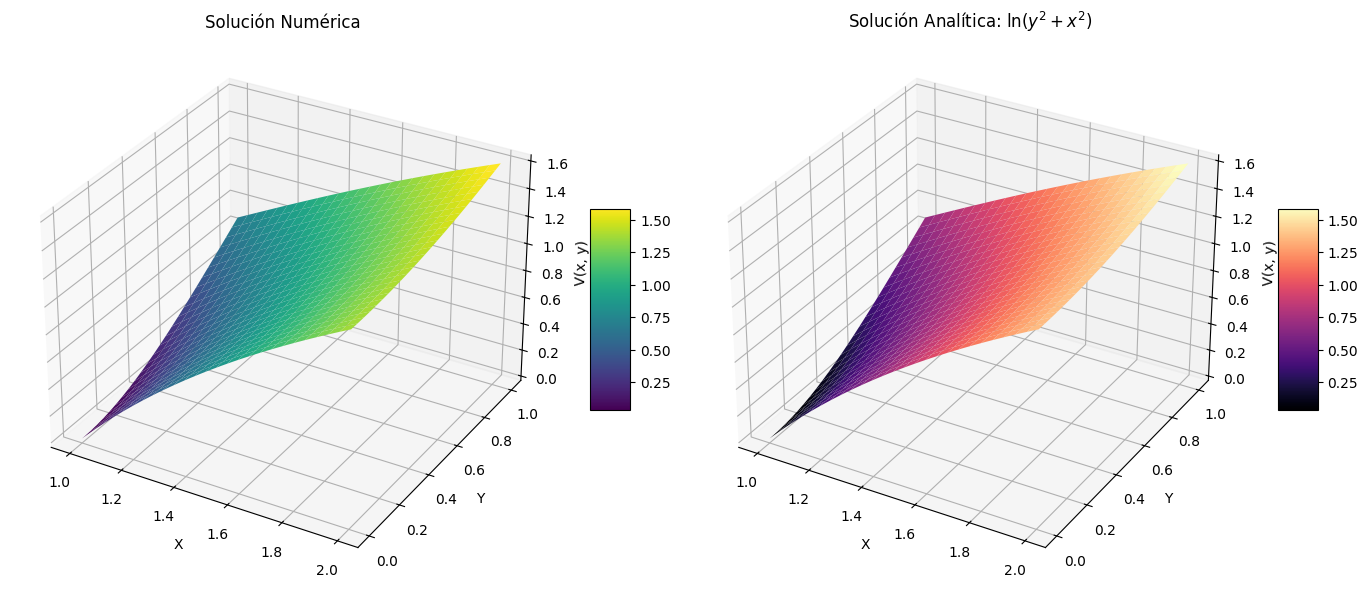

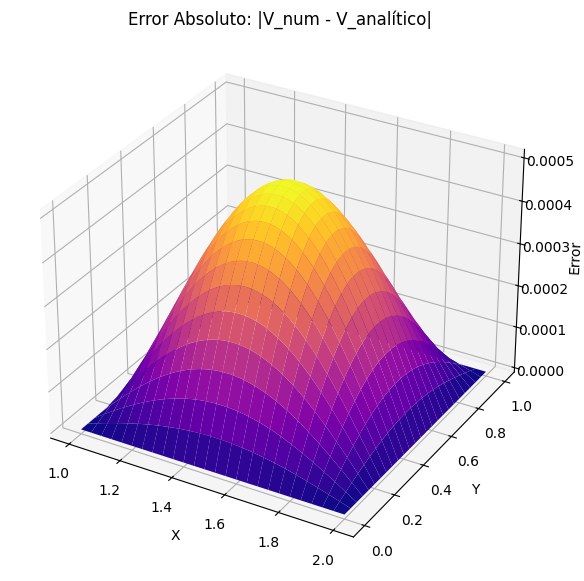

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def initialize_grid(M, N, x_start, x_end, y_start, y_end):
    """
    Inicializa la grilla y la matriz T con las condiciones de contorno dadas.

    Parámetros:
    - M (int): Número de pasos en el eje x.
    - N (int): Número de pasos en el eje y.
    - x_start (float): Valor inicial del rango en x.
    - x_end (float): Valor final del rango en x.
    - y_start (float): Valor inicial del rango en y.
    - y_end (float): Valor final del rango en y.

    Retorna:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.
    - T (ndarray): Matriz inicializada con las condiciones de contorno.
    """
    # Tamaño de la grilla
    h = (x_end - x_start) / M
    k = (y_end - y_start) / N

    # Creación de la grilla
    x = np.linspace(x_start, x_end, M + 1)
    y = np.linspace(y_start, y_end, N + 1)
    X, Y = np.meshgrid(x, y)

    # Inicialización de la matriz T
    T = np.zeros((len(Y), len(X)))

    # Condiciones de contorno
    T[:, 0] = np.log(Y[:, 0]**2 + 1)      # V(1, y) = ln(y^2 + 1) (corresponde a x=1)
    T[:, -1] = np.log(Y[:, -1]**2 + 4)     # V(2, y) = ln(y^2 + 4) (corresponde a x=2)
    T[0, :] = 2 * np.log(X[0, :])         # V(x, 0) = 2ln(x) (corresponde a y=0)
    T[-1, :] = np.log(X[-1, :]**2 + 1)    # V(x, 1) = ln(x^2 + 4) (corresponde a y=1)

    return X, Y, T, h, k

def solve_laplace(T, M, N, h, k, tol=1e-6):
    """
    Aproximación de la solución de la ecuación de Laplace utilizando el método de diferencias finitas.

    Parámetros:
    - T (ndarray): Matriz inicial con condiciones de contorno.
    - M (int): Número de pasos en el eje x.
    - N (int): Número de pasos en el eje y.
    - h (float): Tamaño del paso en x.
    - k (float): Tamaño del paso en y.
    - tol (float): Tolerancia para el criterio de convergencia.

    Retorna:
    - T (ndarray): Matriz con la solución aproximada.
    """
    T_new = T.copy()
    delta = 1.0
    while delta > tol:
        delta = 0.0
        # Iteración sobre los puntos internos
        for i in range(1, N):
            for j in range(1, M):
                T_new[i, j] = 0.25 * (T[i + 1, j] + T[i - 1, j] + T[i, j + 1] + T[i, j - 1])
                delta = max(delta, np.abs(T_new[i, j] - T[i, j]))
        T[:, :] = T_new[:, :]  # Actualizar T después de cada iteración
    return T

def analytical_solution(X, Y):
    """
    Define la solución analítica V(x, y) = ln(y^2 + x^2).

    Parámetros:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.

    Retorna:
    - Z (ndarray): Matriz con los valores de la solución analítica.
    """
    return np.log(Y**2 + X**2)

def plot_comparison_matplotlib(X, Y, T_numerical, T_analytical):
    """
    Grafica la solución numérica y la solución analítica en subplots 3D utilizando Matplotlib.

    Parámetros:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.
    - T_numerical (ndarray): Matriz con la solución numérica.
    - T_analytical (ndarray): Matriz con la solución analítica.
    """
    fig = plt.figure(figsize=(14, 7))

    # Subplot para la solución numérica
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(X, Y, T_numerical, cmap='viridis', edgecolor='none')
    ax1.set_title('Solución Numérica')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('V(x, y)')
    fig.colorbar(surf1, ax=ax1, shrink=0.3, aspect=5)

    # Subplot para la solución analítica
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(X, Y, T_analytical, cmap='magma', edgecolor='none')
    ax2.set_title('Solución Analítica: $\ln(y^2 + x^2)$')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('V(x, y)')
    fig.colorbar(surf2, ax=ax2,shrink=0.3, aspect=5)

    plt.tight_layout()
    plt.show()

# Definir los parámetros de la simulación
M = N = 50
x_inicial = 1.0
x_final = 2.0
y_inicial = 0.0
y_final = 1.0

# Inicializar la grilla y las condiciones de contorno para la ecuación de Laplace
X, Y, T, h, k = initialize_grid(M, N, x_inicial, x_final, y_inicial, y_final)

# Tiempo de ejecución
#start_time = time.time()

# Solucionar la ecuación de Laplace numéricamente (término fuente es 0)
T_numerical = solve_laplace(T, M, N, h, k)

#end_time = time.time()
#print(f"Tiempo de ejecución: {end_time - start_time:.4f} segundos")

# Calcular la solución analítica
T_analytical = analytical_solution(X, Y)

# Graficar la comparación con Matplotlib
plot_comparison_matplotlib(X, Y, T_numerical, T_analytical)
def plot_error(X, Y, T_numerical, T_analytical):
    """
    Grafica el error absoluto entre la solución numérica y la solución analítica.

    Parámetros:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.
    - T_numerical (ndarray): Matriz con la solución numérica.
    - T_analytical (ndarray): Matriz con la solución analítica.
    """
    # Calcular el error absoluto
    error = np.abs(T_numerical - T_analytical)

    # Crear la figura y el subplot en 3D
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, error, cmap='plasma', edgecolor='none')

    # Configuración de la gráfica
    ax.set_title('Error Absoluto: |V_num - V_analítico|')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Error')

    plt.show()

# Llamar a la función para graficar el error absoluto
plot_error(X, Y, T_numerical, T_analytical)

# Tercer ejercicio

Convergió en 3723 iteraciones.
Tiempo: 0.1214s


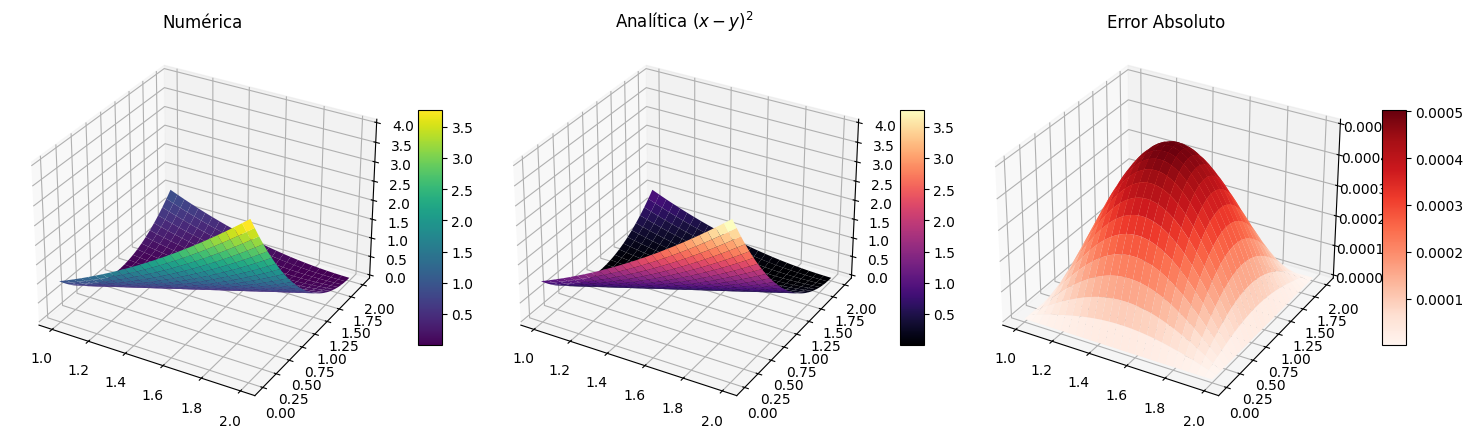

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time

def initialize_grid(M, N, x_start, x_end, y_start, y_end):
    h = (x_end - x_start) / M
    k = (y_end - y_start) / N
    x = np.linspace(x_start, x_end, M + 1)
    y = np.linspace(y_start, y_end, N + 1)
    X, Y = np.meshgrid(x, y)

    # Inicialización de la matriz T
    T = np.zeros((N + 1, M + 1))

    # --- CONDICIONES DE CONTORNO CORREGIDAS ---
    # Deben coincidir con V(x,y) = (x - y)^2
    T[:, 0]  = (x_start - y)**2       # Pared izquierda (x=1)
    T[:, -1] = (x_end - y)**2         # Pared derecha (x=2)
    T[0, :]  = (x - y_start)**2       # Pared inferior (y=0)
    T[-1, :] = (x - y_end)**2         # Pared superior (y=2)
    
    return X, Y, T, h, k

def solve_poisson_vectorized(T, source, h, k, tol=1e-6, max_it=10000):
    """
    Versión optimizada con NumPy (Slicing) para evitar loops lentos.
    """
    T_new = T.copy()
    h2, k2 = h**2, k**2
    denom = 2 * (h2 + k2)
    
    for it in range(max_it):
        T_old = T_new.copy()
        
        # Cálculo vectorizado de los puntos internos
        # T[i,j] = [ (T[i+1,j]+T[i-1,j])*k^2 + (T[i,j+1]+T[i,j-1])*h^2 - f*h^2*k^2 ] / denom
        T_new[1:-1, 1:-1] = (
            ((T_old[2:, 1:-1] + T_old[:-2, 1:-1]) * h2) + 
            ((T_old[1:-1, 2:] + T_old[1:-1, :-2]) * k2) - 
            (source[1:-1, 1:-1] * h2 * k2)
        ) / denom
        
        # Criterio de parada
        if np.max(np.abs(T_new - T_old)) < tol:
            print(f"Convergió en {it} iteraciones.")
            break
            
    return T_new

# --- Ejecución ---
M, N = 50, 50
X, Y, T_init, h, k = initialize_grid(M, N, 1.0, 2.0, 0.0, 2.0)
source = np.full_like(X, 4.0) # f(x,y) = 4

start = time.time()
T_numerical = solve_poisson_vectorized(T_init, source, h, k)
print(f"Tiempo: {time.time() - start:.4f}s")

# Analítica y Error
T_analytical = (X - Y)**2
error = np.abs(T_numerical - T_analytical)

# --- Gráficos ---
fig = plt.figure(figsize=(15, 5))
titles = ['Numérica', 'Analítica $(x-y)^2$', 'Error Absoluto']
data = [T_numerical, T_analytical, error]
cmaps = ['viridis', 'magma', 'Reds']

for i in range(3):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    surf = ax.plot_surface(X, Y, data[i], cmap=cmaps[i], edgecolor='none')
    ax.set_title(titles[i])
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

#    CUARTO EJERCICIO

Tiempo de ejecución: 32.4474 segundos


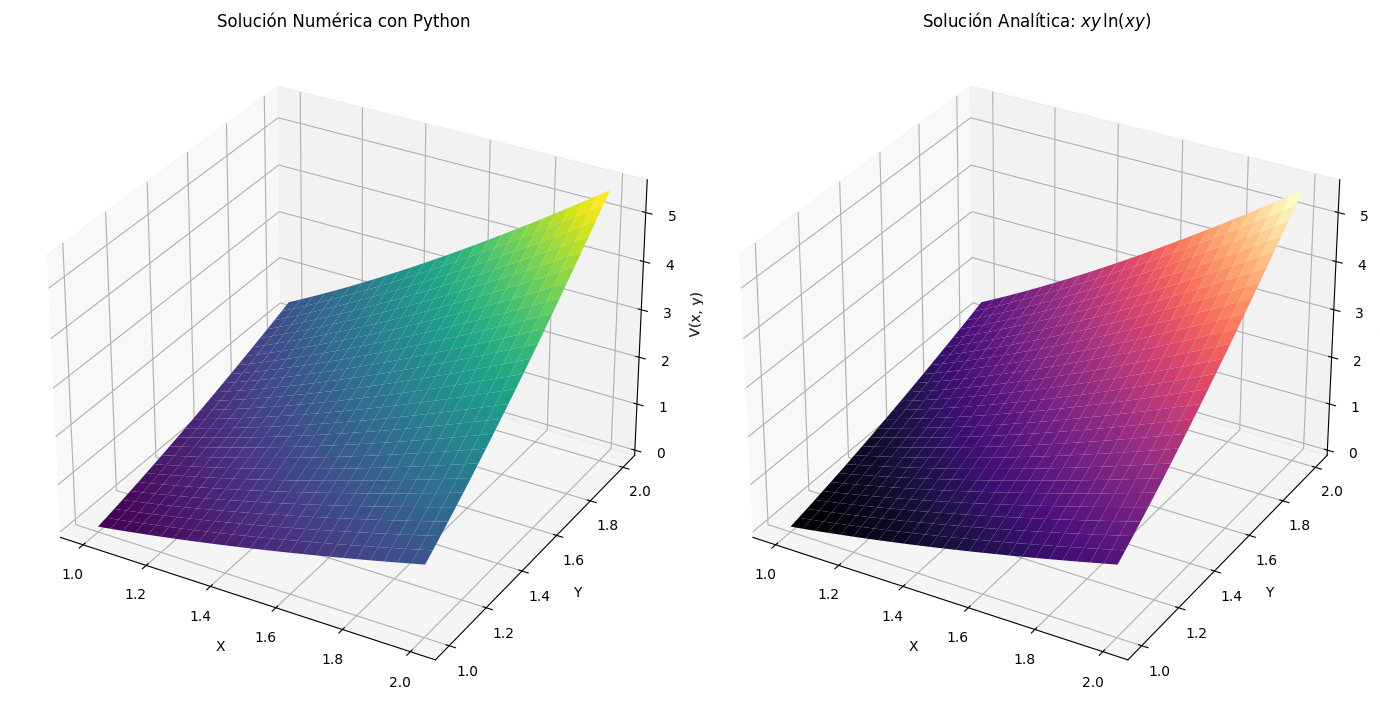

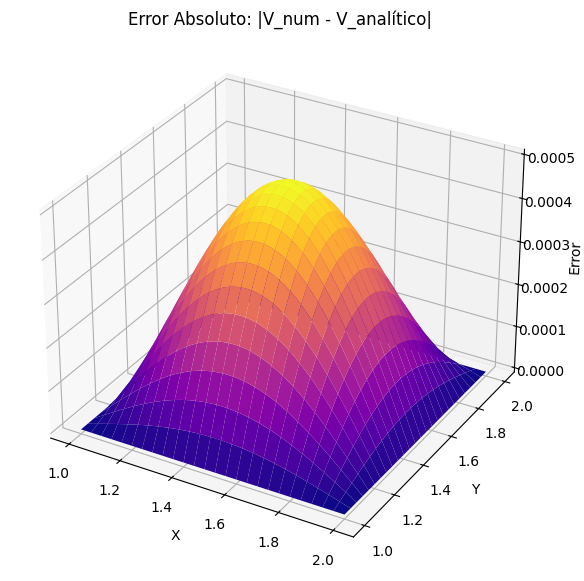

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

def initialize_grid(M, N, x_start, x_end, y_start, y_end):
    h = (x_end - x_start) / M
    k = (y_end - y_start) / N

    x = np.linspace(x_start, x_end, M + 1)
    y = np.linspace(y_start, y_end, N + 1)
    X, Y = np.meshgrid(x, y)

    T = np.zeros_like(X)

    # Condiciones de frontera
    T[:, 0]  = y * np.log(y)                # x = 1
    T[:, -1] = 2 * y * np.log(2 * y)        # x = 2
    T[0, :]  = x * np.log(x)                # y = 1
    T[-1, :] = x * np.log(4 * x**2)         # y = 2

    return X, Y, T, h, k

def fuente(X, Y):
    return X / Y + Y / X

def solve_poisson(T, source, M, N, h, k, tol=1e-6):
    T_new = T.copy()
    delta = 1.0
    while delta > tol:
        delta = 0.0
        for i in range(1, N):
            for j in range(1, M):
                T_new[i, j] = (
                    ((T[i + 1, j] + T[i - 1, j]) * k**2) +
                    ((T[i, j + 1] + T[i, j - 1]) * h**2) -
                    (source[i, j] * h**2 * k**2)
                ) / (2 * (h**2 + k**2))
                delta = max(delta, np.abs(T_new[i, j] - T[i, j]))
        T[:, :] = T_new[:, :]
    return T

def analytical_solution(X, Y):
    return X * Y * np.log(X * Y)

def plot_comparison(X, Y, T_numerical, T_analytical):
    fig = plt.figure(figsize=(14, 7))

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, Y, T_numerical, cmap='viridis', edgecolor='none')
    ax1.set_title('Solución Numérica con Python')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('V(x, y)')

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X, Y, T_analytical, cmap='magma', edgecolor='none')
    ax2.set_title('Solución Analítica: $xy \\, \\ln(xy)$')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('V(x, y)')

    plt.tight_layout()
    plt.show()

# Parámetros de la grilla
M = 50
N = 50
x_start = 1.0
x_end = 2.0
y_start = 1.0
y_end = 2.0

# Inicialización
X, Y, T, h, k = initialize_grid(M, N, x_start, x_end, y_start, y_end)
source = fuente(X, Y)

# Tiempo de ejecución
start_time = time.time()

# Solución numérica
T_numerical = solve_poisson(T, source, M, N, h, k)

end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.4f} segundos")

# Solución analítica
T_analytical = analytical_solution(X, Y)

# Comparación
plot_comparison(X, Y, T_numerical, T_analytical)

def plot_error(X, Y, T_numerical, T_analytical):
    """
    Grafica el error absoluto entre la solución numérica y la solución analítica.

    Parámetros:
    - X (ndarray): Matriz de coordenadas x de la grilla.
    - Y (ndarray): Matriz de coordenadas y de la grilla.
    - T_numerical (ndarray): Matriz con la solución numérica.
    - T_analytical (ndarray): Matriz con la solución analítica.
    """
    # Calcular el error absoluto
    error = np.abs(T_numerical - T_analytical)

    # Crear la figura y el subplot en 3D
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, error, cmap='plasma', edgecolor='none')

    # Configuración de la gráfica
    ax.set_title('Error Absoluto: |V_num - V_analítico|')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Error')

    plt.show()

# Llamar a la función para graficar el error absoluto
plot_error(X, Y, T_numerical, T_analytical)

